# Mesh Generation with GeoDef

This notebook demonstrates three ways to create triangular fault meshes:

1. **From a surface trace + constant dip** — ideal for simple strike-slip or thrust faults
2. **From an exterior polygon** — for arbitrary 3D fault surfaces
3. **From a slab2.0 `.grd` file** — for subduction zone geometries from the global slab2.0 model

All methods produce a `Mesh` dataclass that can be converted to a `Fault` object for forward modeling and inversion.

**Requirements:** `meshpy` (for triangle meshing) and `netCDF4` (for slab2.0 grids). Install with:
```bash
uv pip install meshpy netCDF4
```

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import geodef
from geodef.mesh import from_trace, from_polygon, from_slab2

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper: Visualize a mesh

We'll reuse this function to plot each mesh as a triplot colored by depth.

In [36]:
def plot_mesh(mesh, title="Mesh", ax=None, cmap="viridis_r"):
    """Plot a Mesh with triangles colored by depth."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    triang = mtri.Triangulation(mesh.lon, mesh.lat, mesh.triangles)
    
    # Color by centroid depth (km)
    centers = mesh.centers_geo  # (M, 3): [lon, lat, depth_m]
    depth_km = centers[:, 2] / 1e3
    
    tc = ax.tripcolor(triang, depth_km, cmap=cmap, edgecolors="k", linewidth=0.3)
    plt.colorbar(tc, ax=ax, label="Depth (km)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title} ({mesh.n_triangles} triangles, {mesh.n_nodes} nodes)")
    #ax.set_aspect("equal")
    return ax

---

## 1. Mesh from a surface trace + constant dip

`from_trace()` takes a surface fault trace and projects it down-dip to a specified maximum depth. This is the simplest way to create a mesh for a fault whose geometry is not well constrained at depth.

Here we create a mesh for a subduction interface with a surface trace that curves gently along-strike, dipping to the northeast.

In [37]:
# Define a surface trace curving gently along-strike
trace_lon = np.array([99.0, 99.2, 99.5, 99.9, 100.3])
trace_lat = np.array([-3.0, -2.5, -2.0, -1.5, -1.0])

# Create mesh: 20 degree dip to the east, extending to 40 km depth
mesh_trace = from_trace(
    trace_lon, trace_lat,
    max_depth=40,              # km
    dip=20.0,              # degrees from horizontal
    dip_direction=70.0,    # dip direction: roughly ENE
    target_length=15e3,    # ~15 km triangle edge length
)

print(f"Nodes:     {mesh_trace.n_nodes}")
print(f"Triangles: {mesh_trace.n_triangles}")
print(f"Depth range: {mesh_trace.depth.min()/1e3:.1f} – {mesh_trace.depth.max()/1e3:.1f} km")

Nodes:     274
Triangles: 498
Depth range: 0.0 – 40.0 km


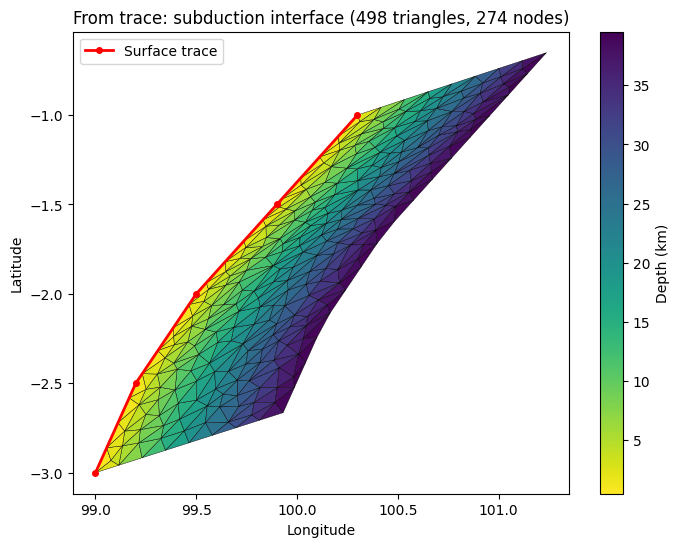

In [38]:
plot_mesh(mesh_trace, title="From trace: subduction interface")
plt.plot(trace_lon, trace_lat, "r-o", markersize=4, linewidth=2, label="Surface trace")
plt.legend()
plt.show()

### Convert to a Fault for modeling

`Fault.from_mesh()` converts the geographic mesh to a triangular fault, automatically deriving per-triangle strike and dip from the vertex geometry.

In [39]:
fault_trace = geodef.Fault.from_mesh(mesh_trace)
print(f"Fault: {fault_trace.n_patches} patches, engine={fault_trace.engine}")
print(f"Depth range: {fault_trace.centers[:, 2].min()/1e3:.1f} – {fault_trace.centers[:, 2].max()/1e3:.1f} km")
print(f"Total area:  {fault_trace.areas.sum()/1e6:.0f} km²")

Fault: 498 patches, engine=tri
Depth range: 0.5 – 39.5 km
Total area:  20469 km²


### Visualize in 3D

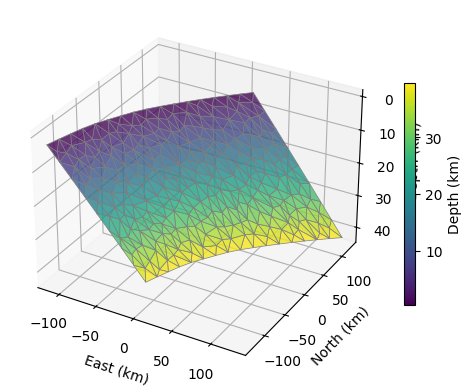

In [40]:
geodef.plot.fault3d(fault_trace, color_by="depth")
plt.show()

---

## 2. Mesh from an exterior polygon

`from_polygon()` creates a mesh from a closed boundary polygon with 3D coordinates. This is useful when you have an outline of the fault surface (e.g., from geologic mapping or a seismicity catalog) but no regular grid.

We'll create a dipping rectangular patch defined by its four corners, then mesh it with triangles.

In [41]:
# Define a trapezoidal polygon that narrows with depth
poly_lon = np.array([99.5, 101.5, 101.2, 99.8])
poly_lat = np.array([-2.0, -2.0, -3.0, -3.0])
poly_depth = np.array([0.0, 0.0, 40e3, 40e3])  # meters, positive down

mesh_poly = from_polygon(
    poly_lon, poly_lat, poly_depth,
    target_length=15e3,  # ~15 km edge length
)

print(f"Nodes:     {mesh_poly.n_nodes}")
print(f"Triangles: {mesh_poly.n_triangles}")
print(f"Depth range: {mesh_poly.depth.min()/1e3:.1f} – {mesh_poly.depth.max()/1e3:.1f} km")

Nodes:     200
Triangles: 357
Depth range: 0.0 – 40.0 km


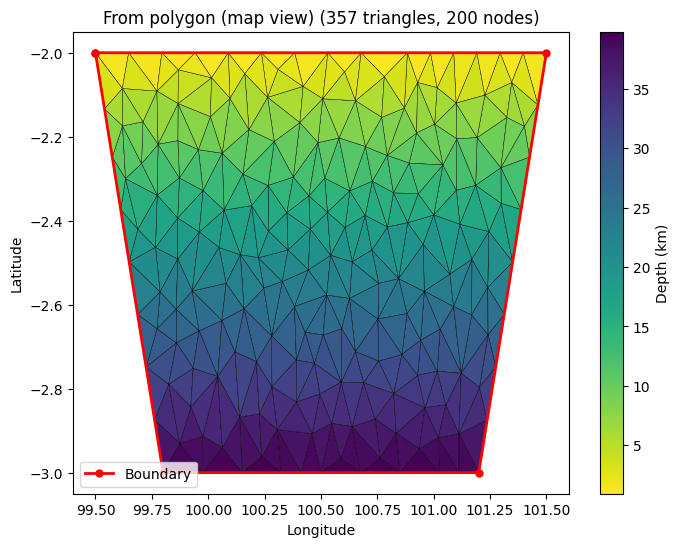

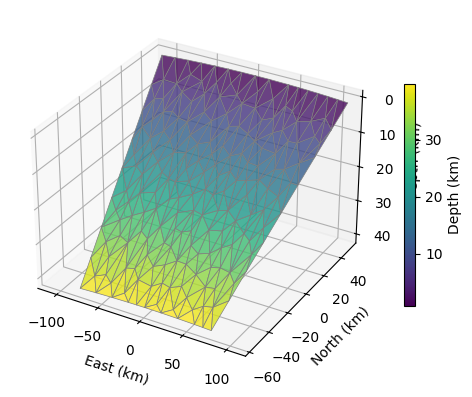

In [42]:
# Map view
plot_mesh(mesh_poly, title="From polygon (map view)")
plt.plot(
    np.append(poly_lon, poly_lon[0]),
    np.append(poly_lat, poly_lat[0]),
    "r-o", markersize=5, linewidth=2, label="Boundary",
)
plt.legend()
plt.show()

# 3D view
fault_poly = geodef.Fault.from_mesh(mesh_poly)
geodef.plot.fault3d(fault_poly, color_by="depth")
plt.show()

### Using a depth function instead of 3D vertices

Alternatively, you can provide a 2D polygon (lon, lat only) with a callable `depth_func(lon, lat)` that returns the depth at any point. This is useful when the depth varies smoothly across the fault surface.

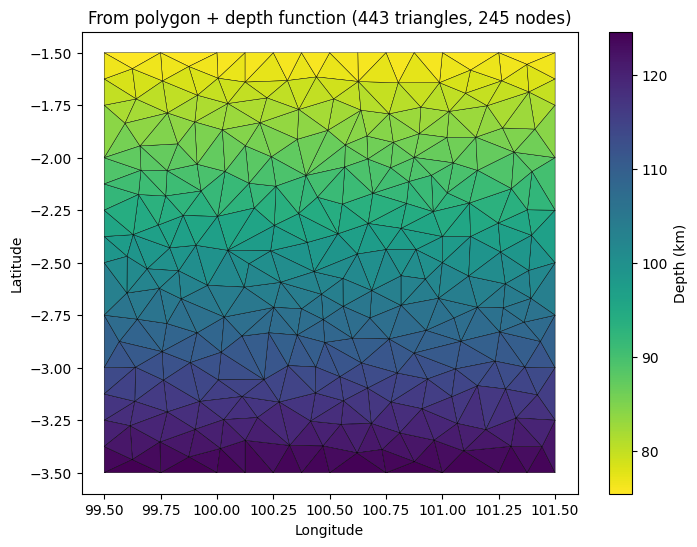

In [43]:
# 2D polygon boundary (no depth)
poly_lon_2d = np.array([99.5, 101.5, 101.5, 99.5])
poly_lat_2d = np.array([-1.5, -1.5, -3.5, -3.5])

# Depth increases from north to south (simulating a dipping surface)
def depth_func(lon, lat):
    """Depth in meters as a function of position."""
    return (-lat - (-1.5)) / (3.5 - 1.5) * 50e3  # 0 at north edge, 50 km at south

mesh_func = from_polygon(
    poly_lon_2d, poly_lat_2d,
    depth_func=depth_func,
    target_length=20e3,
)

plot_mesh(mesh_func, title="From polygon + depth function")
plt.show()

---

## 3. Mesh from a slab2.0 grid

`from_slab2()` loads a slab2.0 NetCDF depth grid, crops it to a specified region, extracts the boundary, and meshes the interior with depth interpolated from the grid. This is the standard workflow for subduction zone studies.

We use a slab2.0 depth grid for the Sumatra subduction zone, included in `examples/data/`.

In [ ]:
# Load the Sumatra slab2.0 depth grid and mesh a subregion
mesh_slab = from_slab2(
    "notebook_data/sum_slab2_dep_02.23.18.grd",
    bounds=(94, 106, -6, 6),  # (lon_min, lon_max, lat_min, lat_max)
    target_length=30,         # ~30 km triangle edge length
)

print(f"Nodes:     {mesh_slab.n_nodes}")
print(f"Triangles: {mesh_slab.n_triangles}")
print(f"Depth range: {mesh_slab.depth.min()/1e3:.1f} – {mesh_slab.depth.max()/1e3:.1f} km")

Nodes:     1550
Triangles: 2965
Depth range: 0.1 – 566.2 km


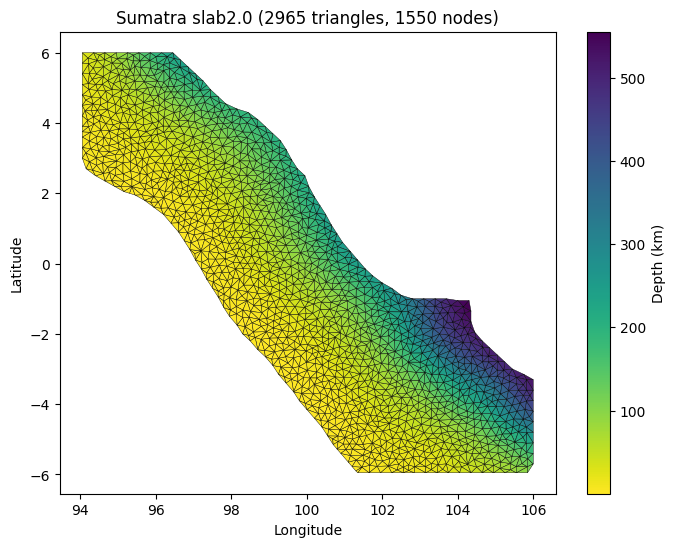

In [45]:
plot_mesh(mesh_slab, title="Sumatra slab2.0")
plt.show()

### Depth-variable refinement

For real inversions, you typically want finer elements near the trench (where data resolution is highest) and coarser elements at depth. Set `depth_growth > 1` to enable this — for example, `depth_growth=3` means triangles at the deepest point have edges 3x longer than at the trench.

In [46]:
mesh_slab_refined = from_slab2(
    "data/sum_slab2_dep_02.23.18.grd",
    bounds=(94, 106, -6, 6),
    target_length=20,      # 20 km at the trench
    depth_growth=10.0,      # 10x coarser at max depth (200 km edges)
)

print(f"Uniform:  {mesh_slab.n_triangles} triangles")
print(f"Refined:  {mesh_slab_refined.n_triangles} triangles")

Uniform:  2965 triangles
Refined:  2385 triangles


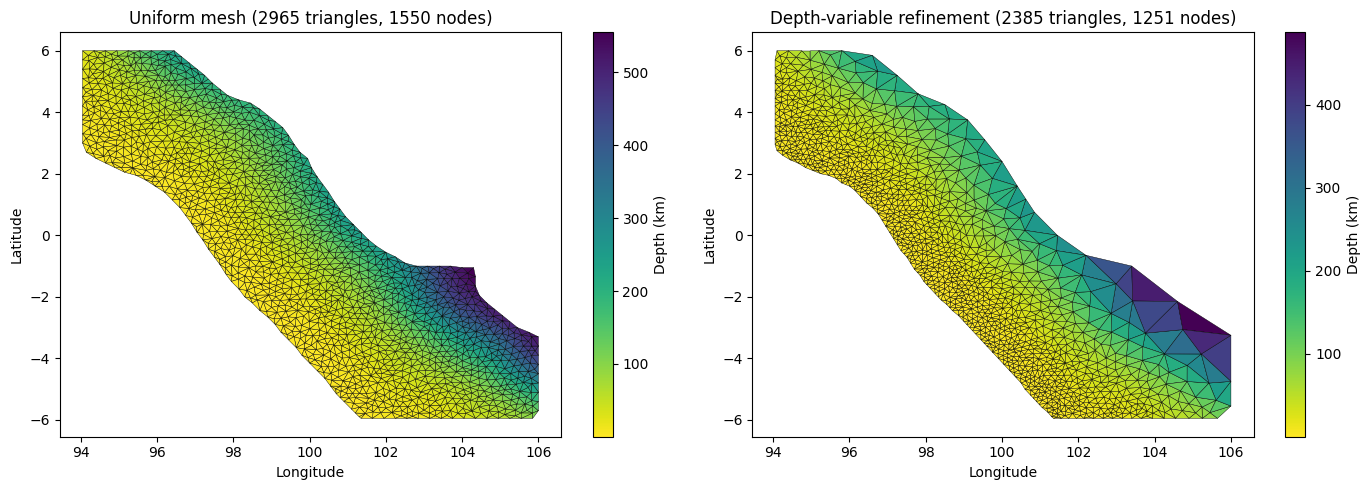

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_mesh(mesh_slab, title="Uniform mesh", ax=axes[0])
plot_mesh(mesh_slab_refined, title="Depth-variable refinement", ax=axes[1])

plt.tight_layout()
plt.show()

### Depth clipping

For geodetic inversions, slip sensitivity drops off rapidly below ~100 km. Use `max_depth` to clip the slab at a given depth (in km).

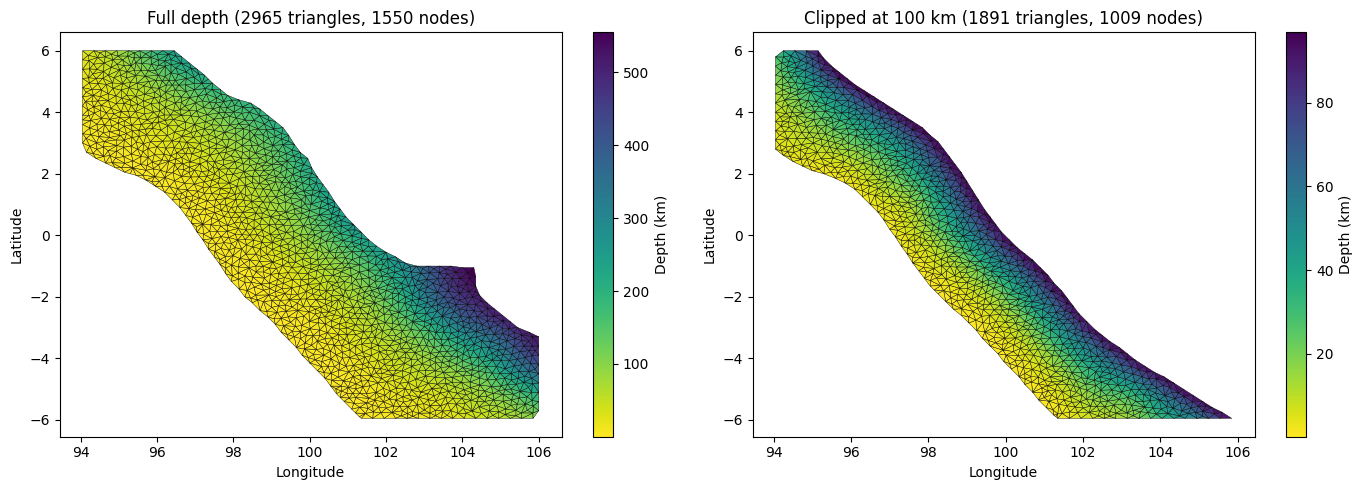

Full:    566 km max depth, 2965 triangles
Clipped: 100 km max depth, 1891 triangles


In [48]:
mesh_clipped = from_slab2(
    "data/sum_slab2_dep_02.23.18.grd",
    bounds=(94, 106, -6, 6),
    target_length=30,
    max_depth=100,         # clip at 100 km
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_mesh(mesh_slab, title="Full depth", ax=axes[0])
plot_mesh(mesh_clipped, title="Clipped at 100 km", ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Full:    {mesh_slab.depth.max()/1e3:.0f} km max depth, {mesh_slab.n_triangles} triangles")
print(f"Clipped: {mesh_clipped.depth.max()/1e3:.0f} km max depth, {mesh_clipped.n_triangles} triangles")

### Convert to Fault and visualize in 3D

In [49]:
fault_slab = geodef.Fault.from_mesh(mesh_slab_refined)
print(f"Fault: {fault_slab.n_patches} patches, engine={fault_slab.engine}")
print(f"Depth range: {fault_slab.centers[:, 2].min()/1e3:.1f} – {fault_slab.centers[:, 2].max()/1e3:.1f} km")
print(f"Total area:  {fault_slab.areas.sum()/1e6:.0f} km²")

Fault: 2385 patches, engine=tri
Depth range: 0.2 – 487.8 km
Total area:  949123 km²


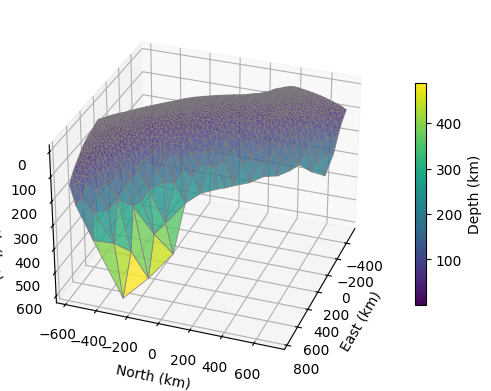

In [50]:
geodef.plot.fault3d(fault_slab, color_by="depth",view=(30,20))
plt.show()

---

## 4. Mesh I/O

Meshes can be saved and loaded in unicycle's `.ned` + `.tri` format for interoperability.

In [51]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    base = os.path.join(tmpdir, "sumatra")
    mesh_slab.save(base)
    
    # Check the files
    print("Saved files:")
    for ext in [".ned", ".tri"]:
        path = base + ext
        size = os.path.getsize(path)
        print(f"  {os.path.basename(path)}: {size:,} bytes")
    
    # Reload and verify
    from geodef.mesh import Mesh
    mesh_reload = Mesh.load(base)
    print(f"\nReloaded: {mesh_reload.n_nodes} nodes, {mesh_reload.n_triangles} triangles")
    print(f"Nodes match:     {np.allclose(mesh_slab.lon, mesh_reload.lon)}")
    print(f"Triangles match: {np.array_equal(mesh_slab.triangles, mesh_reload.triangles)}")

Saved files:
  sumatra.ned: 61,254 bytes
  sumatra.tri: 70,008 bytes

Reloaded: 1550 nodes, 2965 triangles
Nodes match:     True
Triangles match: True


---

## Summary

| Method | Use case | Key parameters |
|--------|----------|----------------|
| `from_trace()` | Known surface trace + dip | `max_depth` (km), `dip`, `dip_direction`, `target_length` (m) |
| `from_polygon()` | Arbitrary 3D boundary or 2D + depth function | `depth` or `depth_func`, `target_length` (m) |
| `from_slab2()` | Subduction zones with slab2.0 grids | `bounds`, `target_length` (km), `depth_growth`, `max_depth` (km), `surface_trace` |
| `from_points()` | Scattered 3D point cloud (e.g., seismicity) | `boundary`, `target_length` (m) |

All methods return a `Mesh` dataclass. Convert to a `Fault` with `Fault.from_mesh(mesh)` to use all of geodef's forward modeling and inversion tools.